In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**IMPORT LIBRARIES**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-27 13:15:33.370759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777295733.901430      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777295734.032197      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777295735.109202      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777295735.109247      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777295735.109249      23 computation_placer.cc:177] computation placer alr

**Deep Learning Libraries**

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

**LOAD DATASET**

In [4]:
#dataset paths
train_dir ="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
test_dir="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"
val_dir="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val"

#verify dataset structure

print("Train classes:",os.listdir(train_dir))
print("Test classes:",os.listdir(test_dir))
print("Validation classes:",os.listdir(val_dir))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']


**Number of images per class**

In [5]:
def count_images(folder):
    counts ={}
    for cls in os.listdir(folder):
        counts[cls]=len(os.listdir(os.path.join(folder,cls)))

    return counts

train_counts=count_images(train_dir)
test_counts =count_images(test_dir)
val_counts = count_images(val_dir)

print("Train images:",train_counts)
print("Test images:",test_counts)
print("Validation images:",val_counts)


Train images: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Test images: {'PNEUMONIA': 390, 'NORMAL': 234}
Validation images: {'PNEUMONIA': 8, 'NORMAL': 8}


**Class Distribution Visualisation** 

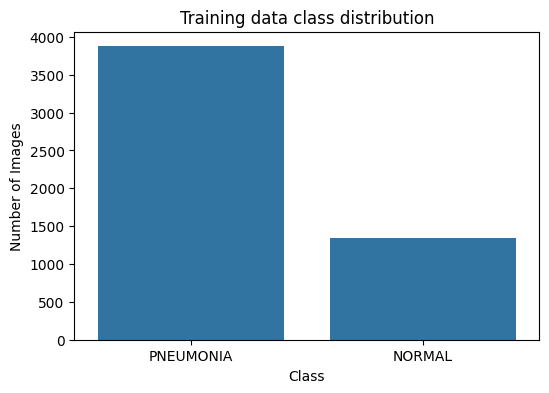

In [6]:
plt.figure(figsize = (6,4))
sns.barplot(x=list(train_counts.keys()),y=list(train_counts.values()))
plt.title("Training data class distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

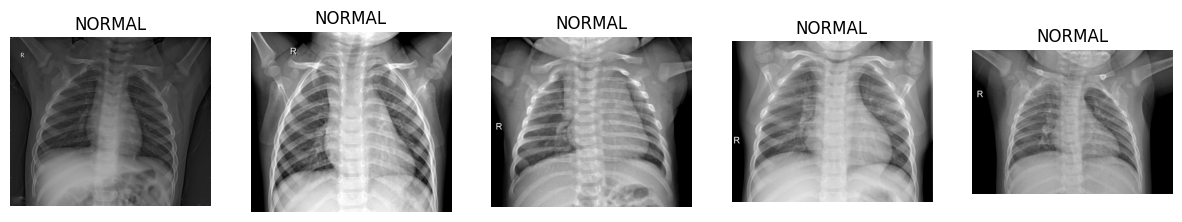

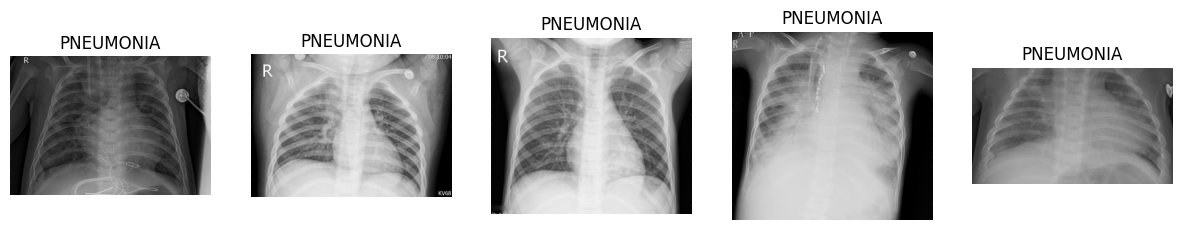

In [7]:
def show_sample_images(folder, cls, n=5):
    cls_folder = os.path.join(folder, cls)
    images = os.listdir(cls_folder)[:n]


    plt.figure(figsize=(15,5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(cls_folder, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(cls)
    plt.show()

show_sample_images(train_dir, "NORMAL")
show_sample_images(train_dir, "PNEUMONIA")

**Corrupt Images Detection**

In [8]:
import os
from PIL import Image

train_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"

corrupt = 0
total = 0

for root, dirs, files in os.walk(train_dir):
    for file in files:
        total += 1
        file_path = os.path.join(root, file)
        
        try:
            img = Image.open(file_path)
            img.verify()
        except:
            corrupt += 1

print("Total Images:", total)
print("Corrupt Images:", corrupt)

Total Images: 5216
Corrupt Images: 0


**Train, Test and Validation Split**

In [9]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)
val_counts = count_images(val_dir)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Validation: {'PNEUMONIA': 8, 'NORMAL': 8}
Test: {'PNEUMONIA': 390, 'NORMAL': 234}


**Data Augmentation(on training data)**

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

In [11]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset = 'training'
)

print("Train classes:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Train classes: {'NORMAL': 0, 'PNEUMONIA': 1}


**Rescaling Validation Data**

In [12]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 16 images belonging to 2 classes.


In [14]:
img_size=224
batch_size=32
channels=3
epochs=15

**Convolutional Neural Network**

In [15]:
#Model Definition
model=models.Sequential()

model.add(layers.Input(shape=(img_size, img_size, 3)))
model.add(layers.Conv2D(32,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(train_data.num_classes,activation='softmax'))


I0000 00:00:1777295817.969166      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777295817.975097      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,795,906 (182.33 MB)

 Trainable params: 47,795,906 (182.33 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

**Model Training**

In [18]:
#Training the Model
history = model.fit(
    train_data,
    steps_per_epoch = train_data.samples // batch_size, #number of steps per epoch
    epochs = 25, #Number of epochs
    validation_data = val_data,
    validation_steps = val_data.samples // batch_size #Validation steps

)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1777295823.154915      86 service.cc:152] XLA service 0x784a70003cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777295823.154961      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777295823.154967      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777295823.576919      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-27 13:17:06.040714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 13:17:06.189323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/163 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.3281 - loss: 4.5923 

I0000 00:00:1777295828.805120      86 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 623ms/step - accuracy: 0.7305 - loss: 1.6736 - val_accuracy: 0.8750 - val_loss: 0.3282
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.8755 - loss: 0.2794 - val_accuracy: 0.8125 - val_loss: 0.4598
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 608ms/step - accuracy: 0.9064 - loss: 0.2421 - val_accuracy: 0.6250 - val_loss: 0.9205
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 619ms/step - accuracy: 0.9224 - loss: 0.2045 - val_accuracy: 0.7500 - val_loss: 0.6295
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 609ms/step - accuracy: 0.9208 - loss: 0.2015 - val_accuracy: 0.7500 - val_loss: 0.5002
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 604ms/step - accuracy: 0.9208 - loss: 0.1971 - val_accuracy: 0.6875 - val_loss: 0.6340
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 585ms/step - accuracy: 0.9302 - loss: 0.1871 - val_accuracy: 0.6250 - val_loss: 0.6751
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 572ms/step - accuracy: 0.9227 - loss: 0.1825 - 

**Model Evaluation**

In [19]:
print("Evaluating Model.......")
val_loss,val_accuracy = model.evaluate(val_data , steps = val_data.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy *100:.2f}%")

Evaluating Model.......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6250 - loss: 1.0052
Validation Accuracy: 62.50%


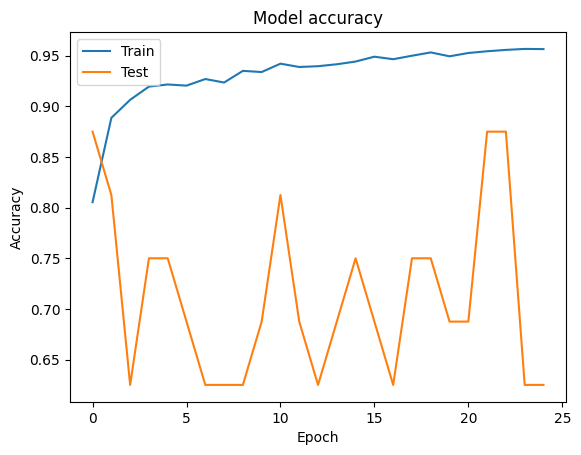

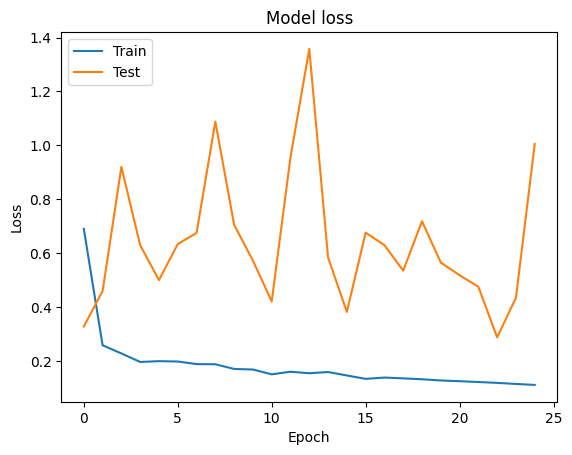

In [20]:
#Plot training and validation accuracy model

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
     


In [21]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name
     

In [22]:

# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_data.class_indices.items()}

In [23]:
class_indices


{0: 'NORMAL', 1: 'PNEUMONIA'}

In [24]:
import json

# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [25]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    
    # ✅ Convert grayscale → RGB
    img = img.convert('RGB')
    
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    return img_array

In [26]:

# Example Usage
image_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person113_bacteria_541.jpeg'

predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
Predicted Class Name: PNEUMONIA


In [27]:

model.save('/content/drive/MyDrive/trained_models/lungs_disease_prediction_model.keras')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/trained_models/lungs_disease_prediction_model.keras'

In [ ]:
model.save('lungs_disease_prediction_model.keras')